In [1]:
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pyart
from netCDF4 import Dataset
from metpy.units import units
from metpy.calc import dewpoint_from_specific_humidity, relative_humidity_from_specific_humidity, wind_speed
from datetime import datetime, timedelta
from wrf import getvar


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
FH_list=[4,6,8,10,12,14]
# dt_list = [datetime(2022,9,15,4),datetime(2022,9,15,6),datetime(2022,9,15,8),
#            datetime(2022,9,15,10),datetime(2022,9,15,12),datetime(2022,9,15,14)]
dt_list = [datetime(2022,7,19,4),datetime(2022,7,19,6),datetime(2022,7,19,8),
           datetime(2022,7,19,10),datetime(2022,7,19,12),datetime(2022,7,19,14)]
# dt_list = [datetime(2021,6,4,4),datetime(2021,6,4,6),datetime(2021,6,4,8),
#            datetime(2021,6,4,10),datetime(2021,6,4,12),datetime(2021,6,4,14)]

In [3]:
def read_wrf(exper):
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/'+exper+'/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    wrfout = Dataset('/glade/campaign/ral/aap/mawilson/nature_runs/'+exper+'/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/'+exper+'/wrfout_d02_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/run_nature_rev/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    
    lon = wrfout.variables['XLONG']
    lat = wrfout.variables['XLAT']
    U10 = wrfout.variables['U10']
    V10 = wrfout.variables['U10']
    T2 = np.asarray(wrfout.variables['T2'])*units('K')
    T2F = T2 .to('degF')
    Q2 = np.asarray(wrfout.variables['Q2'])
    P2 = np.asarray(wrfout.variables['PSFC'][:]/100) * units('hPa')
    Td2 = dewpoint_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    RH2 = relative_humidity_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    SPD10 = wind_speed(np.asarray(U10)*units('m/s'), np.asarray(V10)*units('m/s'))
    cloud=wrfout.variables['QCLOUD']
    #Get fluxes
    LH1 = wrfout.variables['LH'][:]
    HF1 = wrfout.variables['HFX'][:]

    return lon, lat, cloud, RH2, T2, SPD10, LH1, HF1

In [4]:
exper = 'IOP4'

In [5]:
lon_list = []
lat_list = []
cloud_list = []
RH_list = []
T_list = []
SPD_list = []
LH_list = []
HF_list = []

for i in [0,1,2,3,4,5]:

    dt = dt_list[i]
    lon1, lat1, cloud1, RH21, T21, SPD101, LH1, HF1 = read_wrf(exper)
    lon_list.append(lon1)
    lat_list.append(lat1)
    cloud_list.append(cloud1)
    RH_list.append(RH21)
    T_list.append(T21)
    SPD_list.append(SPD101)
    LH_list.append(LH1)
    HF_list.append(HF1)

In [6]:
#Make a map to show the domain
lati = 37.15
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

# LL1 = (cenlon1-10.,cenlat1-4.0,ccrs.PlateCarree())
# UR1 = (cenlon1+6.,cenlat1+8.0,ccrs.PlateCarree())

# #Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-90.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

In [7]:
# cenlon2 = cenlon1+0.2
# cenlat2 = cenlat1+1.5

# LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
# UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

# figure_mosaic = """
# ABC
# DEF
# """

# fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})

# ax_l = ['A','B','C','D','E','F']

# for i in [0,1,2,3,4,5]:
#     dt = dt_list[i]

#     #Load in observations
#     ObsFile = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', skip_header=1)
#     ObsFileStr = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', 
#                                skip_header=1,usecols=(0),dtype='str')
#     Obs_Ti = ObsFile[:,1]
#     Obs_R2i = ObsFile[:,5]
#     Obs_Si = ObsFile[:,6]
#     Obs_lon = ObsFile[:,8]
#     Obs_lat = ObsFile[:,9]
#     Obs_V = ObsFile[:,11]
    
#     plt.sca(ax=axes[ax_l[i]])
#     axes[ax_l[i]].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
#     axes[ax_l[i]].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)

#     cloud1 = np.copy(np.asarray(cloud_list[i]))*1000
#     cloud2 = np.copy(cloud1)
#     cloud1[cloud1<0.001] = np.nan
#     cloudmax1 = np.nanmax(cloud2[0,0:3,:,:],axis=0)
#     cloudmax1[cloudmax1<0.001] = np.nan
#     cloudy_points = cloudmax1[~np.isnan(cloudmax1)].shape
#     print(np.ndarray.flatten(cloudmax1).shape[0])
#     box_points = np.ndarray.flatten(cloudmax1).shape
#     print(cloudy_points[0])
#     wrf_cloud_c = (cloudy_points[0]/box_points[0])*100
#     print(wrf_cloud_c)

    
#     #axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
#     cb = axes[ax_l[i]].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)
#     # cg = plt.colorbar(cb, ax = axes[ax_l[i]], shrink = .7, pad = 0.06, fraction=0.046)
#     # cg.ax.tick_params(labelsize=25)
#     # cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)
#     cn=axes[ax_l[i]].scatter(Obs_lon, Obs_lat, c=Obs_V, s=200, edgecolors='k', cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=0, vmax=10, transform=ccrs.PlateCarree())
#     plt.title('Nature Run '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC \n Fog Coverage: %.0f %%' % wrf_cloud_c, size=25)
# plt.subplots_adjust(right=0.8)

# #cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
# cg = plt.colorbar(cb, ax = axes.ravel().tolist(), shrink = 1.0, pad = 0.06, fraction=0.046)
# cg.ax.tick_params(labelsize=25)
# cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)
# # plt.suptitle('100 m Mini-Ensemble for June 4 2021 \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=30)
# # plt.savefig('IOPJUNE_100m5panel_cloud.png',bbox_inches='tight')

# # plt.suptitle('100 m Mini-Ensemble for July 19 2022 \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=30)
# # plt.savefig('IOP4_100m5panel_cloud.png',bbox_inches='tight')

# #plt.suptitle('Nature Run for IOP6', size=30)
# #plt.savefig('IOP6_FINAL_6panelfog.png',bbox_inches='tight')
# plt.savefig('IOP4_R1_6panelfog.png',bbox_inches='tight')
# #plt.savefig('IOPJUNE_FINAL_6panelfog.png',bbox_inches='tight')
# #plt.savefig('km_opt_FINAL_6panelfog.png',bbox_inches='tight')


1251936
3256
0.2600771924443422


/glade/derecho/scratch/mawilson/tmp/ipykernel_81311/2691635528.py:48: RuntimeWarning: All-NaN slice encountered
  cb = axesf[i].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


1251936
82203
6.566070470055978


/glade/derecho/scratch/mawilson/tmp/ipykernel_81311/2691635528.py:48: RuntimeWarning: All-NaN slice encountered
  cb = axesf[i].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


1251936
180298
14.401534902742632


...

/glade/derecho/scratch/mawilson/tmp/ipykernel_81311/2691635528.py:48: RuntimeWarning: All-NaN slice encountered
  cb = axesf[i].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


1251936
194164
15.509099506684048


/glade/derecho/scratch/mawilson/tmp/ipykernel_81311/2691635528.py:48: RuntimeWarning: All-NaN slice encountered
  cb = axesf[i].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


1251936
6
0.0004792577256345372


/glade/derecho/scratch/mawilson/tmp/ipykernel_81311/2691635528.py:48: RuntimeWarning: All-NaN slice encountered
  cb = axesf[i].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


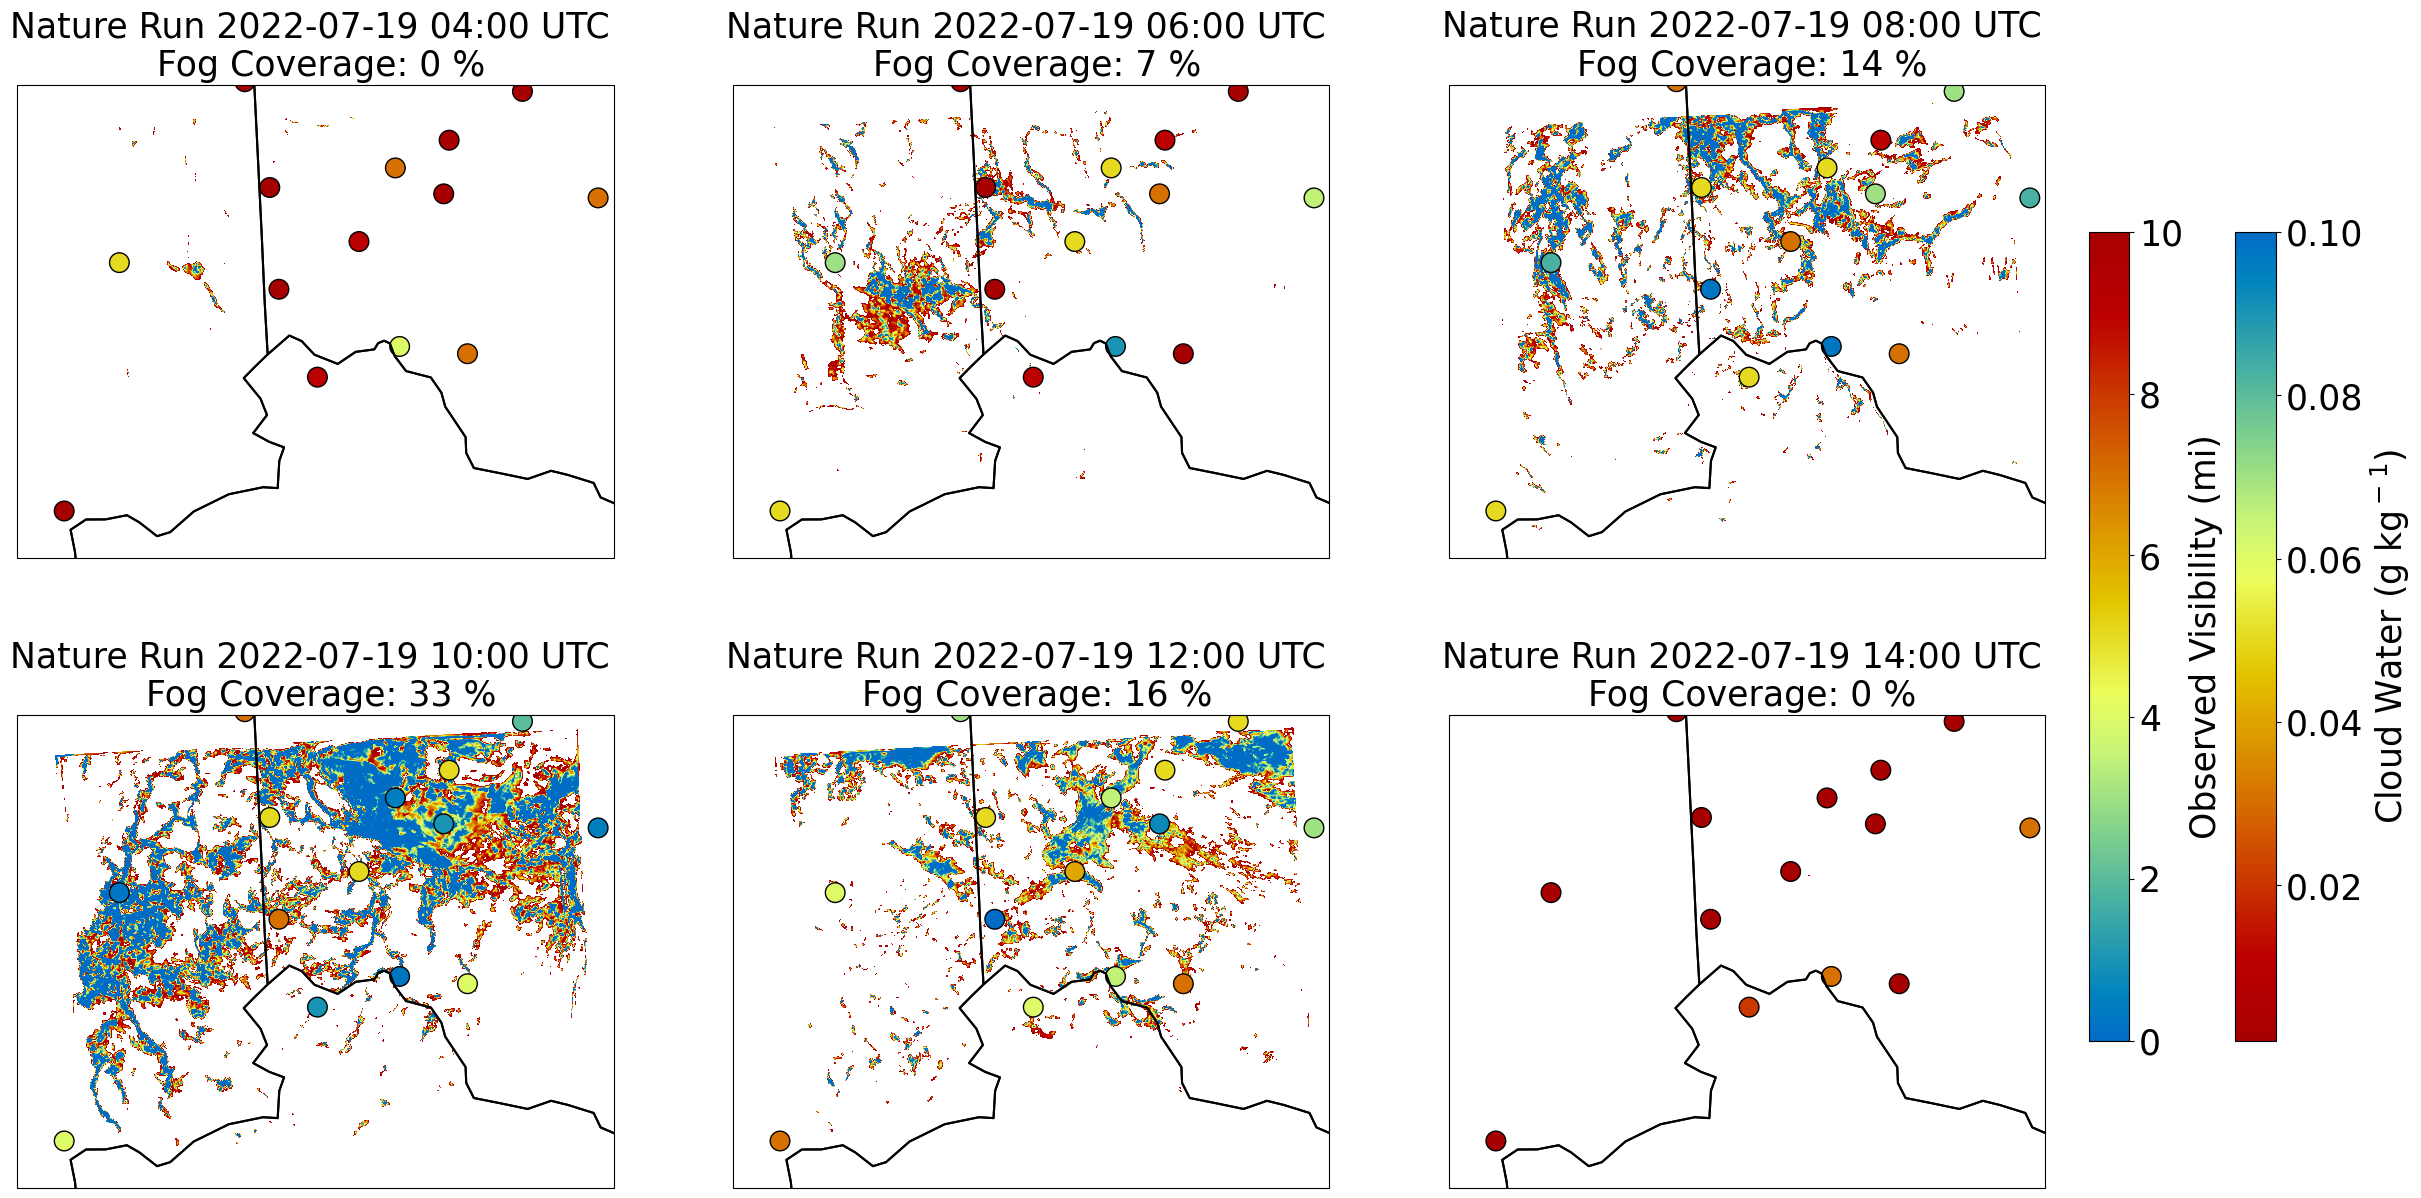

In [8]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

# figure_mosaic = """
# ABC
# DEF
# """

#fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(30,15), subplot_kw={'projection': crs})
ax_l = ['A','B','C','D','E','F']
axesf=axes.flat
for i in [0,1,2,3,4,5]:
    dt = dt_list[i]

    #Load in observations
    ObsFile = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', skip_header=1)
    ObsFileStr = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', 
                               skip_header=1,usecols=(0),dtype='str')
    Obs_Ti = ObsFile[:,1]
    Obs_R2i = ObsFile[:,5]
    Obs_Si = ObsFile[:,6]
    Obs_lon = ObsFile[:,8]
    Obs_lat = ObsFile[:,9]
    Obs_V = ObsFile[:,11]
    
    plt.sca(ax=axesf[i])
    axesf[i].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
    axesf[i].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)

    cloud1 = np.copy(np.asarray(cloud_list[i]))*1000
    cloud2 = np.copy(cloud1)
    cloud1[cloud1<0.001] = np.nan
    cloudmax1 = np.nanmax(cloud2[0,0:3,:,:],axis=0)
    cloudmax1[cloudmax1<0.001] = np.nan
    cloudy_points = cloudmax1[~np.isnan(cloudmax1)].shape
    print(np.ndarray.flatten(cloudmax1).shape[0])
    box_points = np.ndarray.flatten(cloudmax1).shape
    print(cloudy_points[0])
    wrf_cloud_c = (cloudy_points[0]/box_points[0])*100
    print(wrf_cloud_c)

    
    #axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
    cb = axesf[i].pcolormesh(lon_list[i][0,:,:], lat_list[i][0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)
    # cg = plt.colorbar(cb, ax = axes[ax_l[i]], shrink = .7, pad = 0.06, fraction=0.046)
    # cg.ax.tick_params(labelsize=25)
    # cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)
    cn=axesf[i].scatter(Obs_lon[~np.isnan(Obs_V)], Obs_lat[~np.isnan(Obs_V)], c=Obs_V[~np.isnan(Obs_V)], s=200, edgecolors='k', cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=0, vmax=10, transform=ccrs.PlateCarree())
    plt.title('Nature Run '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC \n Fog Coverage: %.0f %%' % wrf_cloud_c, size=25)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cg = plt.colorbar(cb, ax = axes.ravel().tolist(), shrink = 0.7, pad = 0.02, fraction=0.046)
cg.ax.tick_params(labelsize=25)
cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)

co = plt.colorbar(cn, ax = axes.ravel().tolist(), shrink = 0.7, pad = 0.02, fraction=0.046)
co.ax.tick_params(labelsize=25)
co.set_label("Observed Visibility (mi)",size = 25)
# plt.suptitle('100 m Mini-Ensemble for June 4 2021 \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=30)
# plt.savefig('IOPJUNE_100m5panel_cloud.png',bbox_inches='tight')

# plt.suptitle('100 m Mini-Ensemble for July 19 2022 \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=30)
# plt.savefig('IOP4_100m5panel_cloud.png',bbox_inches='tight')

#plt.suptitle('Nature Run for IOP6', size=30)
#plt.savefig('IOP6_FINAL_6panelfog.png',bbox_inches='tight')
plt.savefig('IOP4_R1_6panelfog.png',bbox_inches='tight')
#plt.savefig('IOP6_R1_6panelfog.png',bbox_inches='tight')
#plt.savefig('JUNE_R1_6panelfog.png',bbox_inches='tight')

#plt.savefig('IOPJUNE_FINAL_6panelfog.png',bbox_inches='tight')
#plt.savefig('km_opt_FINAL_6panelfog.png',bbox_inches='tight')


In [9]:
wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/run_nature_rev/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')


FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/mawilson/20210604_newcase/run_nature_rev/wrfout_d02_2022-07-19_14:00:00'

In [ ]:
print(axes.flat[0])

In [ ]:
print(axes)

In [ ]:
print(axes.ravel)

In [ ]:
print(hgt[1:,0,0]-hgt[:-1,0,0])
print(hgt[:,0,0]-hgt[0,0,0])

print(hgt[1:,100,100]-hgt[:-1,100,100])
print(hgt[:,100,100]-hgt[0,100,100])